In [67]:
import pandas as pd
import random
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

### Introduction

In [9]:
train = pd.read_json('data/train.json')
test = pd.read_json('data/test.json')

In [10]:
train_qun_99 = train['price'].quantile(0.99)
train_qun_01 =  train['price'].quantile(0.01)
train = train[(train['price'] < train_qun_99) & (train['price'] > train_qun_01)]

test_qun_99 = test['price'].quantile(0.99)
test_qun_01 =  test['price'].quantile(0.01)
test = test[(test['price'] < test_qun_99) & (test['price'] > test_qun_01)]

In [11]:
train['interest_level'] = train['interest_level'].astype('category').cat.rename_categories(new_categories={'low': 0, 'medium': 1, 'high': 2})
train['interest_level'] = train['interest_level'].astype(int)

In [12]:
from collections import Counter

features = []
for feature in train['features']:
    features.extend(feature)

most_common_features = Counter(features).most_common(20)

In [13]:
most_common_features

[('Elevator', 25375),
 ('Hardwood Floors', 23146),
 ('Cats Allowed', 23135),
 ('Dogs Allowed', 21652),
 ('Doorman', 20479),
 ('Dishwasher', 20081),
 ('No Fee', 17793),
 ('Laundry in Building', 16082),
 ('Fitness Center', 12989),
 ('Pre-War', 8971),
 ('Laundry in Unit', 8437),
 ('Roof Deck', 6417),
 ('Outdoor Space', 5132),
 ('Dining Room', 4890),
 ('High Speed Internet', 4223),
 ('Balcony', 2898),
 ('Swimming Pool', 2643),
 ('Laundry In Building', 2564),
 ('New Construction', 2504),
 ('Terrace', 2177)]

In [14]:
top_features = []
for tuple in most_common_features:
    feature, cnt = tuple
    top_features.append(feature)

for feature in top_features:
    mask = train['features'].map(lambda x: feature in x if isinstance(x, list) else False)
    train[feature] = mask.astype(float)

for feature in top_features:
    mask = test['features'].map(lambda x: feature in x if isinstance(x, list) else False)
    test[feature] = mask.astype(float)

In [15]:
train['created'] = pd.to_datetime(train['created'])

### Data Split

In [16]:
class DataSplit:
    def __init__(self, data):
        self.data = data

    def train_test_split(self, test_size=0.2):
        np.random.seed(21)
        num_test_objects = round(self.data.shape[0] * test_size)
        indices = np.arange(self.data.shape[0])
        np.random.shuffle(indices)

        test_ind = indices[:num_test_objects]
        train_ind = indices[num_test_objects:]

        train = self.data.iloc[train_ind]
        test = self.data.iloc[test_ind]

        return train, test
    def train_test_val_split(self, test_size, validation_size):
        np.random.seed(21)
        num_test_objects = round(self.data.shape[0] * test_size)
        num_val_objects = round(self.data.shape[0] * validation_size)
        indices = np.arange(self.data.shape[0])
        np.random.shuffle(indices)

        test_ind = indices[:num_test_objects]
        val_ind = indices[num_test_objects:num_test_objects+num_val_objects]
        train_ind = indices[num_test_objects+num_val_objects:]

        train = self.data.iloc[train_ind]
        val = self.data.iloc[val_ind]
        test = self.data.iloc[test_ind]

        return train, test, val
    
    def train_test_by_date(self, date_split):
        data = self.data.sort_values(by='created')
        date_split = pd.to_datetime(date_split)

        train_mask = data['created'] < date_split
        test_mask = data['created'] >= date_split

        train = data[train_mask]
        test = data[test_mask]

        return train, test
    
    def train_val_test_by_date(self, validation_date, test_date):
        data = self.data.sort_values(by='created') 
        validation_date = pd.to_datetime(validation_date)
        test_date = pd.to_datetime(test_date)

        if validation_date > test_date:
            train_mask = data['created'] < test_date 
            test_mask = (test_date <= data['created']) & (data['created'] < validation_date)
            val_mask = data['created'] >= validation_date
        else:
            train_mask = data['created'] < validation_date
            val_mask = (validation_date <= data['created']) & (data['created'] < test_date)
            test_mask = data['created'] >= test_date

        return data[train_mask], data[val_mask], data[test_mask]


In [135]:
split = DataSplit(train)
train_part, test_part = split.train_test_split(test_size=0.2)
print(train_part.shape)
print(test_part.shape)

(38674, 35)
(9669, 35)


In [139]:
train_part, val_part, test_part = split.train_test_val_split(validation_size=0.1, test_size=0.1)
print(train_part.shape)
print(val_part.shape)
print(test_part.shape)

(38675, 35)
(4834, 35)
(4834, 35)


In [138]:
from sklearn.model_selection import train_test_split

X = train.drop('price', axis=1)
y = train['price']

X_train, X_test, y_test, y_train = train_test_split(X, y, test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(38674, 34)
(9669, 34)


In [ ]:
train_part, val_part, test_part = split.train_val_test_by_date(validation_date='2016-05-30 04:52:07', test_date='2016-05-14 04:52:07')

In [131]:
train_part.tail(5)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
69579,1.0,0,98b69ff44ef3a67cbb5c1803efbd635d,2016-05-14 04:51:21,,Dorchester Road,"[Elevator, Cats Allowed, Dogs Allowed]",40.6414,7012633,-73.9599,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63661,1.0,0,82d49232d090bf090288e95dde39d2bd,2016-05-14 04:51:30,,East 25th Street,[Elevator],40.7390,7012640,-73.9791,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68973,1.0,1,2ebee72d2307b321491705fcb865aaf3,2016-05-14 04:51:44,Big & Bright Murray Hill / Midtown East Queen ...,E 36 Street,"[Loft, Hardwood Floors]",40.7462,7012650,-73.9759,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
64944,1.0,0,ee92ad1183f255ff3abda099dc567215,2016-05-14 04:52:03,,East 5th Street,"[Cats Allowed, Dogs Allowed]",40.7261,7012658,-73.9870,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69375,1.0,1,d9b4a13d6460ca00a0b479d162971684,2016-05-14 04:52:05,,West 63rd Street,"[Elevator, Cats Allowed]",40.7712,7012663,-73.9813,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [133]:
test_part.head(5)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
76937,1.0,3,d3402959c919a43a315059f0e9368d8b,2016-05-14 04:52:07,LIVE IN THE HEART OF THE TRENDIEST NEIGHBORHOO...,Greenwich St.,"[Swimming Pool, Roof Deck, Balcony, Doorman, E...",40.7180,7012664,-74.0112,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
76550,1.0,0,9f60193f1599b23e425e9ebe4e76b0e8,2016-05-14 04:52:07,We don't have a description for this b...,Stanton Street,[],40.7224,7012666,-73.9922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63447,1.0,1,0,2016-05-14 04:52:30,Fully-Renovated 1-Bedroom Apartment. Beautiful...,200 East 71st Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7688,7012676,-73.9608,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57140,1.0,0,3a956bd42c50f06ac84cf072fc514f5f,2016-05-14 04:52:39,NO FEEAPARTMENT: Gorgeous studio apartment wit...,West 42nd Street,"[Swimming Pool, Roof Deck, Doorman, Elevator, ...",40.7613,7012682,-73.9998,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
43821,2.0,2,8dbdafdf2f5f3ac31ecd0c41c6858669,2016-05-14 04:52:42,This beautiful 2 bedroom in the heart ...,E 28th St,"[Fitness Center, Cats Allowed, Dogs Allowed]",40.7437,7012685,-73.9851,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [134]:
val_part.head(5)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
72054,1.0,1,240c90a25f43280bd489939f99e98723,2016-05-30 04:57:11,This oversized one bedroom with a formal dinin...,East 56th Street,"[Elevator, Cats Allowed, Dogs Allowed, Exclusive]",40.7602,7084154,-73.9689,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43927,1.0,2,39be6a109f77f42e46646beefbbb1388,2016-05-30 04:57:12,,Columbus Avenue,"[Cats Allowed, Dogs Allowed, Exclusive]",40.7848,7084155,-73.9730,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79715,1.0,1,f51e3f6b4886bb775ab9a6a0f34ff0ef,2016-05-30 04:57:15,,East 69th Street,"[Elevator, Cats Allowed, Dogs Allowed, Exclusive]",40.7675,7084157,-73.9607,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74600,1.0,4,b9f488ccbda179edc69f36f80f242e23,2016-05-30 04:57:42,,West 162nd Street,[Exclusive],40.8369,7084173,-73.9416,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44707,1.0,2,415814c4b23b8b868a304ac844f37a75,2016-05-30 04:57:50,Massive 2 bedroom duplex apartment in a prime ...,East 4th Street,"[Dishwasher, No Fee, Cats Allowed, Dogs Allowed]",40.7260,7084177,-73.9892,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Cross-validation methods

In [17]:
import math
from sklearn.base import clone

class CrossValidation:
    def __init__(self, data):
        self.data = data

    def KFold(self, n_splits, shuffle=True):
        fold_size = int(math.ceil(self.data.shape[0] / n_splits))
        indices = np.arange(self.data.shape[0])

        if shuffle:
            np.random.seed(21)
            np.random.shuffle(indices)

        for i in range(n_splits):
            start = i*fold_size

            if start >= self.data.shape[0]:  
                break 

            stop = min(start + fold_size, self.data.shape[0])
            test = indices[start:stop]
            train = np.concatenate([indices[:start], 
                                    indices[stop:]])
            yield train, test 

    def cross_val_score(self, kf, X, y, scoring, model):
        metrics = []

        for train_index, test_index in kf:
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]

            model_copy = clone(model)
            model_copy.fit(X_train, y_train)

            y_pred = model_copy.predict(X_test)
            metric = scoring(y_test, y_pred)
            metrics.append(metric)

        return sum(metrics) / len(metrics)
    
    def GroupKFold(self, group_field, n_splits):
        groups = self.data[group_field].values
        unique_groups = np.unique(groups)

        if n_splits > len(unique_groups):
            raise ValueError('There can be no more n_splits than groups')
        
        np.random.seed(21)
        np.random.shuffle(unique_groups)

        group_folds = np.array_split(unique_groups, n_splits)
        ind_to_pos = {idx: pos for pos, idx in enumerate(self.data.index)}
        grouped = self.data.groupby(group_field)
        for fold in group_folds:
            test_ind = []
            for group in fold:
                test_ind.extend([ind_to_pos[idx] for idx in grouped.groups[group]])
            train_ind = [x for x in range(len(self.data)) if x not in test_ind]

            yield train_ind, test_ind

    def label_distribution(self, n_objects, n_folds):
        whole_part = n_objects // n_folds
        remains = n_objects % n_folds

        distribution = [whole_part] * n_folds

        for i in range(remains):
            distribution[i] += 1 

        return distribution

    def StratifiedKFold(self, k, stratify_field, shuffle=True):
        np.random.seed(21)

        unique_labels = self.data[stratify_field].unique()
        ind_to_cls = {label:[] for label in unique_labels}
        for i in range(self.data.shape[0]):
            price_value = self.data[stratify_field].iloc[i]
            ind_to_cls[price_value].append(i)

        if shuffle:
            for label in ind_to_cls:
                np.random.shuffle(ind_to_cls[label])

        cls_distribution = {}
        for cls in unique_labels:
            n_objects = len(ind_to_cls[cls])
            cls_distribution[cls] = self.label_distribution(n_objects, k)

        folds = [[] for _ in range(k)]

        for cls in cls_distribution:
            indices = ind_to_cls[cls]
            distribution = cls_distribution[cls]
            start = 0
            for i in range(k):
                stop = start + distribution[i]
                folds[i].extend(indices[start:stop])
                start = stop
            
        if shuffle:
            for fold_ind in range(k):
                np.random.shuffle(folds[fold_ind])
        
        for fold_ind in range(k):
            test = folds[fold_ind]
            train = []

            for idx in range(k):
                if idx != fold_ind:
                    train.extend(folds[idx])

            yield train, test
    
    def TimeSeriesSplit(self, k, data_field):
        data = self.data.sort_values(by=data_field)
        dates = pd.to_datetime(data[data_field])
        n_dates =  len(dates)
        unique_dates = dates.unique()
        n_unique = len(unique_dates)

        for i in range(k):
            split_point = int(n_unique * (i + 1) / (k + 1))
            split_point = max(split_point, 1)  
            next_point = int(n_unique * (i + 2) / (k + 1))

            train_mask = dates < unique_dates[split_point]

            if next_point < n_unique:
                test_mask = (dates >= unique_dates[split_point]) & (dates < unique_dates[next_point])
            else:
                test_mask = dates >= unique_dates[split_point]

            train_indices = np.where(train_mask)[0]
            test_indices = np.where(test_mask)[0]

            yield train_indices, test_indices

In [18]:
top_features.extend(['bathrooms', 'bedrooms', 'price', 'created', 'interest_level'])
train_part = train[top_features]

In [19]:
train_copy = train_part.copy()
train_part.loc[:, 'created'] = train_part['created'].astype('int64') // 10**9

/var/folders/jb/zkfyxcwx1_z7_qyw8llwwzxw0000gn/T/ipykernel_29002/2124168913.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1466056527 1464759873 1465917599 ... 1461649323 1461034053 1461130440]' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  train_part.loc[:, 'created'] = train_part['created'].astype('int64') // 10**9


In [22]:
def Scaler(type, X):
    if type == 'Standard':
        X_scaled = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) +  1e-8)
        return X_scaled
    elif type == 'MinMax':
        X_scaled = (X - np.min(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0) +  1e-8)
        return X_scaled

In [271]:
from sklearn import tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score

cv = CrossValidation(train_part)
kf = cv.KFold(n_splits=5)
X = train_part.drop('price', axis=1)
y = train_part['price']
X_scaled = Scaler('Standard', X)

model = tree.DecisionTreeRegressor()
kf = cv.KFold(n_splits=5)

kf_score = cv.cross_val_score(kf, X_scaled, y, scoring=r2_score, model=model)
kf_score


0.4058928897861064

In [274]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=21)
scores = cross_val_score(model, X_scaled, y, scoring='r2', cv=kf)

scores.mean()

np.float64(0.41227534818694556)

In [163]:
group_kf = cv.GroupKFold(group_field='bathrooms', n_splits=5)
group_kf_score = cv.cross_val_score(group_kf, X_scaled, y, scoring=r2_score, model=model)

group_kf_score

-1.1220942959096076

In [167]:
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=5)
scores = []
for train_index, test_index in group_kfold.split(X_scaled, y, groups=X_scaled['bathrooms']):
    X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = r2_score(y_pred, y_test)
    scores.append(score)

sum(scores) / len(scores)


-0.7471057615511031

In [175]:
grouped_train = train_part.drop('price', axis=1)
grouped_train['grouped_price'] = pd.qcut(train_part['price'], q=6, labels=[0, 1, 2, 3, 4, 5])

cv = CrossValidation(grouped_train)
stratified_kf = cv.StratifiedKFold(k=5, stratify_field='grouped_price')

X = grouped_train.drop('grouped_price', axis=1)
y = grouped_train['grouped_price']
X_scaled = Scaler('Standard', X)

model = tree.DecisionTreeClassifier()
skf_score = cv.cross_val_score(stratified_kf, X_scaled, y, scoring=accuracy_score, model=model)

skf_score

0.48250962584723317

In [180]:
from sklearn.model_selection import StratifiedKFold

stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)
skf_score = cross_val_score(model, X_scaled, y, scoring='accuracy', cv=stratified_kf)

skf_score.mean()

np.float64(0.48257242316882437)

In [188]:
train_part.columns

Index(['Elevator', 'Hardwood Floors', 'Cats Allowed', 'Dogs Allowed',
       'Doorman', 'Dishwasher', 'No Fee', 'Laundry in Building',
       'Fitness Center', 'Pre-War', 'Laundry in Unit', 'Roof Deck',
       'Outdoor Space', 'Dining Room', 'High Speed Internet', 'Balcony',
       'Swimming Pool', 'Laundry In Building', 'New Construction', 'Terrace',
       'bathrooms', 'bedrooms', 'price'],
      dtype='object')

In [243]:
cv = CrossValidation(train_copy)
X = train_part.drop('price', axis=1)
y = train_part['price']
model = tree.DecisionTreeRegressor()

tscv = cv.TimeSeriesSplit(6, 'created')
tscv_score = cv.cross_val_score(tscv, X, y, scoring=r2_score, model=model)

tscv_score

0.33445382627062065

In [236]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
train_copy = train_copy.sort_values('created')
X = train_copy.drop(['price', 'created'], axis=1)
y = train_copy['price']
tscv_score = cross_val_score(model, X, y, scoring='r2', cv=tscv)

tscv_score.mean()

np.float64(0.5494659525516827)

### Feature Selection

In [70]:
splitter = DataSplit(train_part)
train, test, val = splitter.train_test_val_split(validation_size=0.2, test_size=0.2)

X_train = Scaler('Standard', train.drop('price', axis=1))
y_train = train['price']

X_test = Scaler('Standard', test.drop('price', axis=1))
y_test = test['price']

X_val = Scaler('Standard', val.drop('price', axis=1))
y_val = val['price']

In [ ]:
model = Lasso()
model.fit(X_train, y_train)

results = pd.DataFrame(columns=['RMSE', 'MAE', 'R2'])
datasets = ['Train', 'Test', 'Validation']
data_pairs = [(X_train, y_train), (X_test, y_test), (X_val, y_val)]

for idx, (dataset_name, (X, y)) in enumerate(zip(datasets, data_pairs)):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))  
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    results.loc[dataset_name] = [rmse, mae, r2]

results


,RMSE,MAE,R2
Train,1003.408456,691.406864,0.602902
Test,995.096734,689.903904,0.616097
Validation,978.504240,679.764345,0.598364


In [288]:
coeff = pd.DataFrame({'Features': X_train.columns, 'coefficient': np.abs(model.coef_)}).sort_values('coefficient', ascending=False)
coeff = coeff[:10]

coeff

,Features,coefficient
20,bathrooms,683.969375
21,bedrooms,527.420582
4,Doorman,272.551588
23,interest_level,261.476712
10,Laundry in Unit,165.291797
0,Elevator,109.075473
8,Fitness Center,97.284083
7,Laundry in Building,89.834291
5,Dishwasher,70.008422
14,High Speed Internet,57.277512


In [298]:
important_features = coeff['Features']
X_train = train[important_features]
y_train = train['price']
X_test = test[important_features]
X_val = val[important_features]

model = Lasso()
model.fit(X_train, y_train)

results = pd.DataFrame(columns=['RMSE', 'MAE', 'R2'])
datasets = ['Train', 'Test', 'Validation']
data_pairs = [(X_train, y_train), (X_test, y_test), (X_val, y_val)]

for idx, (dataset_name, (X, y)) in enumerate(zip(datasets, data_pairs)):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))  
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    results.loc[dataset_name] = [rmse, mae, r2]

results

,RMSE,MAE,R2
Train,1008.506820,693.728428,0.598856
Test,1000.929193,693.809331,0.611584
Validation,982.749967,679.015467,0.594871


In [299]:
train_part.isnull().sum()

Elevator               0
Hardwood Floors        0
Cats Allowed           0
Dogs Allowed           0
Doorman                0
Dishwasher             0
No Fee                 0
Laundry in Building    0
Fitness Center         0
Pre-War                0
Laundry in Unit        0
Roof Deck              0
Outdoor Space          0
Dining Room            0
High Speed Internet    0
Balcony                0
Swimming Pool          0
Laundry In Building    0
New Construction       0
Terrace                0
bathrooms              0
bedrooms               0
price                  0
created                0
interest_level         0
dtype: int64

In [318]:
corr_matrix = np.abs(train_part.corr()['price']).sort_values()
corr_matrix.drop('price', inplace=True)
corr_matrix = corr_matrix[-10:]

corr_matrix

Outdoor Space      0.153005
interest_level     0.199652
Elevator           0.215907
Dining Room        0.223166
Dishwasher         0.226014
Fitness Center     0.233688
Laundry in Unit    0.259999
Doorman            0.281959
bedrooms           0.547310
bathrooms          0.670808
Name: price, dtype: float64

In [339]:
top_features = corr_matrix.index.to_list()
top_features

['Outdoor Space',
 'interest_level',
 'Elevator',
 'Dining Room',
 'Dishwasher',
 'Fitness Center',
 'Laundry in Unit',
 'Doorman',
 'bedrooms',
 'bathrooms']

In [340]:
X_train = train[top_features]
y_train = train['price']
X_test = test[top_features]
X_val = val[top_features]

model = Lasso()
model.fit(X_train, y_train)
data_pairs = [(X_train, y_train), (X_test, y_test), (X_val, y_val)]

for idx, (dataset_name, (X, y)) in enumerate(zip(datasets, data_pairs)):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))  
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    results.loc[dataset_name] = [rmse, mae, r2]

results

,RMSE,MAE,R2
Train,1015.322283,700.641177,0.593416
Test,1007.894214,699.544935,0.606159
Validation,989.060225,684.100478,0.589651


In [354]:
from sklearn.inspection import permutation_importance

model = Lasso()
model.fit(X_train, y_train)

result = permutation_importance(model,X_test, y_test, 
                                scoring='neg_mean_absolute_percentage_error',
                                n_repeats=10, random_state=21)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean': result.importances_mean,
    'Std': result.importances_std
})

importance_df.sort_values('Mean', ascending=False, inplace=True)

In [355]:
importance_df

,Feature,Mean,Std
21,bedrooms,0.077817,0.001057
20,bathrooms,0.075716,0.001314
4,Doorman,0.026388,0.000785
23,interest_level,0.020614,0.000783
10,Laundry in Unit,0.008344,0.000492
0,Elevator,0.005073,0.000349
8,Fitness Center,0.003298,0.000308
5,Dishwasher,0.002759,0.000211
7,Laundry in Building,0.001864,0.000082
14,High Speed Internet,0.000835,0.000182


In [356]:
important_features = importance_df['Feature'].to_list()
important_features = important_features[:10]
X_train = train[important_features]
y_train = train['price']
X_test = test[important_features]
X_val = val[important_features]

model = Lasso()
model.fit(X_train, y_train)

results = pd.DataFrame(columns=['RMSE', 'MAE', 'R2'])
datasets = ['Train', 'Test', 'Validation']
data_pairs = [(X_train, y_train), (X_test, y_test), (X_val, y_val)]

for idx, (dataset_name, (X, y)) in enumerate(zip(datasets, data_pairs)):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))  
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    results.loc[dataset_name] = [rmse, mae, r2]

results

,RMSE,MAE,R2
Train,1008.506679,693.730734,0.598856
Test,1000.928673,693.811890,0.611584
Validation,982.750649,679.018524,0.594870


In [37]:
import shap


model = Lasso()
model.fit(X_train, y_train)

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test)



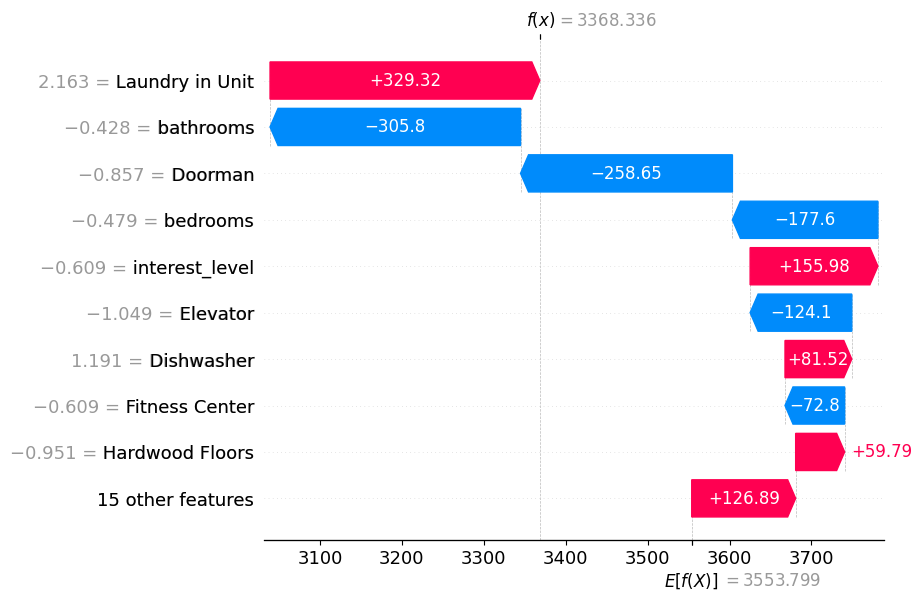

In [33]:
shap.plots.waterfall(shap_values[0])

In [47]:
shap_df = pd.DataFrame(explainer.shap_values(X_test), columns=X_test.columns)
shap_df = shap_df.abs().mean().sort_values(ascending=False)
shap_df[:10]

bathrooms              500.902897
bedrooms               441.863718
Doorman                273.174984
interest_level         220.748995
Laundry in Unit        144.176777
Elevator               108.487353
Fitness Center          92.656692
Laundry in Building     82.888657
Dishwasher              69.274886
Hardwood Floors         57.051570
dtype: float64

In [50]:
top_features = shap_df[:10].index.to_list()
X_train = train[top_features]
y_train = train['price']
X_test = test[top_features]
X_val = val[top_features]

model = Lasso()
model.fit(X_train, y_train)

results = pd.DataFrame(columns=['RMSE', 'MAE', 'R2'])
datasets = ['Train', 'Test', 'Validation']
data_pairs = [(X_train, y_train), (X_test, y_test), (X_val, y_val)]

for idx, (dataset_name, (X, y)) in enumerate(zip(datasets, data_pairs)):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))  
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    results.loc[dataset_name] = [rmse, mae, r2]

results


,RMSE,MAE,R2
Train,1009.337600,695.005157,0.598195
Test,1002.174243,693.877326,0.610617
Validation,982.952150,679.150803,0.594704


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1]
}

model = ElasticNet()
gs = GridSearchCV(model, param_grid=param_grid, cv=5)
gs.fit(X_train, y_train)

In [64]:
best_params = gs.best_params_
best_model = ElasticNet(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(rmse, mae, r2)


995.0947516274422 689.9729734277864 0.6160988722863052


In [74]:
import optuna 

study = optuna.create_study(
        direction='maximize', 
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )

def objective(trial):
        alpha = trial.suggest_float('alpha', 1e-4, 100, log=True)
        l1_ratio = trial.suggest_float('l1_ratio', 0, 1)
        
        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=10000,
            random_state=42
        )
        
        scores = cross_val_score(
            model, X_train, y_train,
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        return scores.mean()

study.optimize(objective, n_trials=100,  show_progress_bar=True)


[I 2025-12-30 15:34:26,995] A new study created in memory with name: no-name-23f33f39-f666-4ff6-ad2a-145f5777c0a3
Best trial: 0. Best value: -1.00945e+06:   2%|▏         | 2/100 [00:00<00:20,  4.87it/s]

[I 2025-12-30 15:34:27,253] Trial 0 finished with value: -1009450.5050017622 and parameters: {'alpha': 0.017670169402947963, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: -1009450.5050017622.
[I 2025-12-30 15:34:27,424] Trial 1 finished with value: -1235227.8348341424 and parameters: {'alpha': 2.4658329458549115, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: -1009450.5050017622.


Best trial: 0. Best value: -1.00945e+06:   3%|▎         | 3/100 [00:00<00:23,  4.08it/s]

[I 2025-12-30 15:34:27,716] Trial 2 finished with value: -1009451.0667045966 and parameters: {'alpha': 0.0008632008168602552, 'l1_ratio': 0.15599452033620265}. Best is trial 0 with value: -1009450.5050017622.


Best trial: 0. Best value: -1.00945e+06:   5%|▌         | 5/100 [00:01<00:22,  4.21it/s]

...

[I 2025-12-30 15:34:49,956] Trial 95 finished with value: -1009455.6647422623 and parameters: {'alpha': 0.010728479965845555, 'l1_ratio': 0.3187908414405562}. Best is trial 43 with value: -1009444.3447673464.
[I 2025-12-30 15:34:50,114] Trial 96 finished with value: -2409292.7816032832 and parameters: {'alpha': 69.90427913994704, 'l1_ratio': 0.36256176059479706}. Best is trial 43 with value: -1009444.3447673464.


Best trial: 43. Best value: -1.00944e+06:  99%|█████████▉| 99/100 [00:23<00:00,  4.82it/s]

[I 2025-12-30 15:34:50,333] Trial 97 finished with value: -1009444.8100080311 and parameters: {'alpha': 0.0057555842842580375, 'l1_ratio': 0.5039239749501584}. Best is trial 43 with value: -1009444.3447673464.
[I 2025-12-30 15:34:50,475] Trial 98 finished with value: -2275285.3721125005 and parameters: {'alpha': 34.46167323930757, 'l1_ratio': 0.42321870642413983}. Best is trial 43 with value: -1009444.3447673464.


Best trial: 43. Best value: -1.00944e+06: 100%|██████████| 100/100 [00:23<00:00,  4.21it/s]

[I 2025-12-30 15:34:50,726] Trial 99 finished with value: -1009449.0248534381 and parameters: {'alpha': 0.0033501265207149375, 'l1_ratio': 0.6415637539967787}. Best is trial 43 with value: -1009444.3447673464.


In [75]:
best_model = ElasticNet(
        **study.best_params,
        max_iter=10000,
        random_state=42
    )
best_model.fit(X_train, y_train)
    
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")


MSE: 990148.8079
RMSE: 995.0622
R²: 0.6161
MAE: 690.0044
